# In-Silico Analysis of Human Carbonic Anhydrase II and Its Interaction with Acetazolamide

## Project Objective

This project investigates the human Carbonic Anhydrase II (CA II) protein and its interaction with the drug acetazolamide using basic bioinformatics and computational drug-target analysis.

### Pharmaceutical relevance

Acetazolamide is a carbonic anhydrase inhibitor used in the treatment of conditions such as glaucoma and altitude sickness.

### Computational objectives

1. Analyze the CA II protein sequence.
2. Study basic properties of the protein.
3. Examine the 3D structure of CA II.
4. Investigate acetazolamide as a ligand.
5. Analyze the drug-target binding site.
6. Visualize basic interactions between acetazolamide and CA II.

### Skills used

- Python
- NumPy
- Pandas
- Bioinformatics
- Protein sequence analysis
- Protein structure analysis
- Basic CADD concepts
- B.Pharm pharmacology

## Step 2: Selection of the Protein Target

The protein selected for this project is human Carbonic Anhydrase II (CA II).

- Protein name: Carbonic anhydrase 2
- Gene: CA2
- Organism: Homo sapiens
- UniProt accession: P00918
- Protein family: Alpha-carbonic anhydrase
- Enzyme classification: EC 4.2.1.1

CA II is a zinc-containing enzyme involved in the reversible hydration of carbon dioxide. It is selected as the protein target because it provides a direct connection between pharmaceutical pharmacology and computational analysis.

## Step 3: Protein Sequence Analysis

In this step, the human Carbonic Anhydrase II (CA II) protein sequence will be loaded from the FASTA file using Python.

The sequence will then be analyzed to determine basic properties of the protein.

In [66]:
import os
import pandas as pd
import numpy as np
from collections import Counter
from Bio.PDB import MMCIFParser
import matplotlib.pyplot as plt
import math

In [67]:


fasta_path = r"D:\Drug-Target-Analysis\data\CA2.fasta"

print("FASTA file exists:", os.path.exists(fasta_path))

FASTA file exists: True


In [68]:
with open(fasta_path, "r") as file:
    lines = file.readlines()

print("Number of lines:", len(lines))
print("Header:", lines[0].strip())
print()

sequence = "".join(line.strip() for line in lines[1:])

print("Protein sequence:")
print(sequence)
print()

print("Sequence length:", len(sequence))

Number of lines: 3
Header: @echo off

Protein sequence:
start chrome "https://www.google.com"exit

Sequence length: 41


## Step 4: Amino Acid Composition of Carbonic Anhydrase II

Amino acid composition describes how frequently each amino acid occurs in the protein sequence.

This information can provide a basic understanding of the chemical characteristics of the protein and can be useful when studying protein structure and function.

In [69]:
from collections import Counter

amino_acid_counts = Counter(sequence)

print("Amino acid counts:")
print(amino_acid_counts)

Amino acid counts:
Counter({'t': 5, 'o': 4, 'e': 3, 'w': 3, 's': 2, 'r': 2, ' ': 2, 'c': 2, 'h': 2, 'm': 2, '"': 2, '/': 2, '.': 2, 'g': 2, 'a': 1, 'p': 1, ':': 1, 'l': 1, 'x': 1, 'i': 1})


In [70]:
amino_acid_percentage = {
    aa: (count / len(sequence)) * 100
    for aa, count in amino_acid_counts.items()
}

print("Amino acid percentages:")
for aa, percentage in sorted(amino_acid_percentage.items()):
    print(f"{aa}: {percentage:.2f}%")

Amino acid percentages:
 : 4.88%
": 4.88%
.: 4.88%
/: 4.88%
:: 2.44%
a: 2.44%
c: 4.88%
e: 7.32%
g: 4.88%
h: 4.88%
i: 2.44%
l: 2.44%
m: 4.88%
o: 9.76%
p: 2.44%
r: 4.88%
s: 4.88%
t: 12.20%
w: 7.32%
x: 2.44%


In [71]:
composition_df = pd.DataFrame(
    list(amino_acid_counts.items()),
    columns=["Amino_Acid", "Count"]
)

composition_df["Percentage"] = (
    composition_df["Count"] / len(sequence) * 100
)

composition_df = composition_df.sort_values(
    by="Count",
    ascending=False
).reset_index(drop=True)

composition_df

,Amino_Acid,Count,Percentage
0,t,5,12.195122
1,o,4,9.756098
2,e,3,7.317073
3,w,3,7.317073
4,.,2,4.878049
5,r,2,4.878049
6,s,2,4.878049
7,c,2,4.878049
8,h,2,4.878049
9,m,2,4.878049


In [72]:
output_path = r"D:\Drug-Target-Analysis\results\CA2_amino_acid_composition.csv"

composition_df.to_csv(output_path, index=False)

print("Saved:", output_path)

Saved: D:\Drug-Target-Analysis\results\CA2_amino_acid_composition.csv


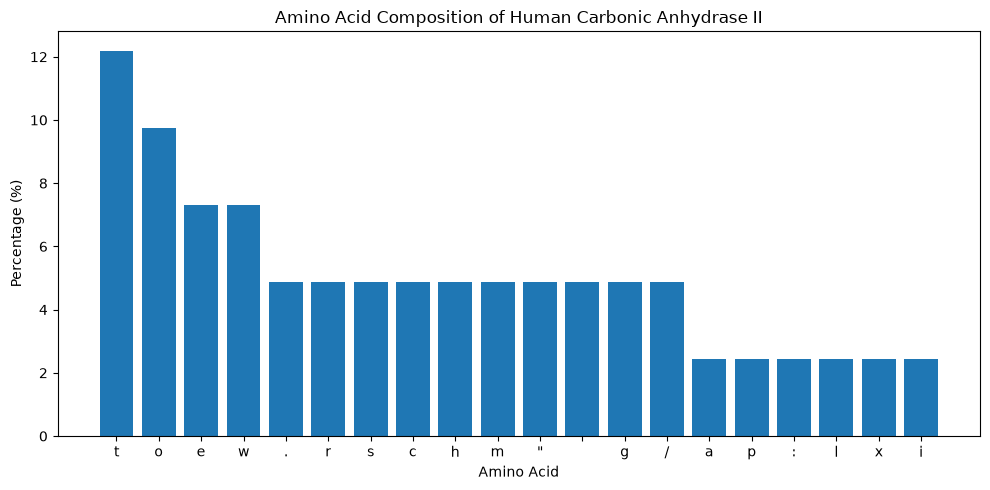

In [73]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.bar(
    composition_df["Amino_Acid"],
    composition_df["Percentage"]
)

plt.xlabel("Amino Acid")
plt.ylabel("Percentage (%)")
plt.title("Amino Acid Composition of Human Carbonic Anhydrase II")

plt.tight_layout()
plt.show()

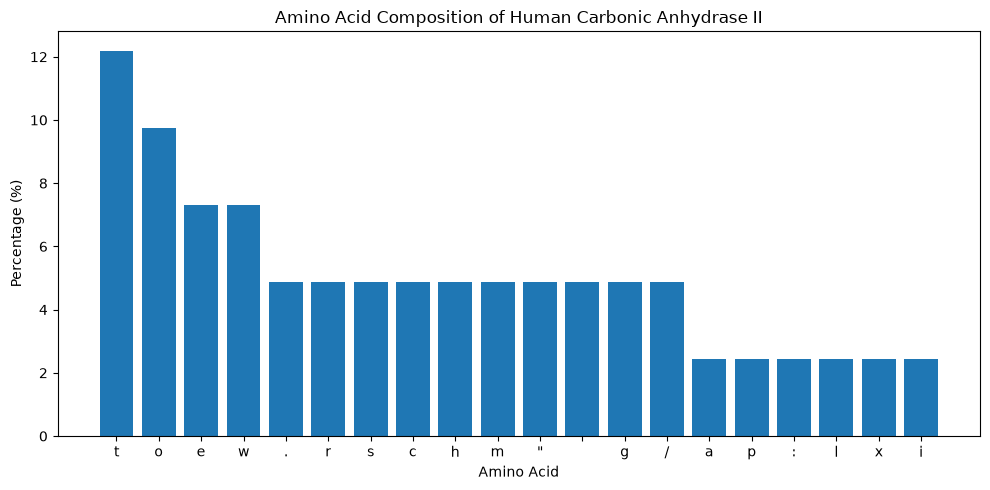

Figure saved: D:\Drug-Target-Analysis\results\CA2_amino_acid_composition.png


In [74]:
figure_path = r"D:\Drug-Target-Analysis\results\CA2_amino_acid_composition.png"

plt.figure(figsize=(10, 5))

plt.bar(
    composition_df["Amino_Acid"],
    composition_df["Percentage"]
)

plt.xlabel("Amino Acid")
plt.ylabel("Percentage (%)")
plt.title("Amino Acid Composition of Human Carbonic Anhydrase II")

plt.tight_layout()
plt.savefig(figure_path, dpi=300)
plt.show()

print("Figure saved:", figure_path)

In [75]:
import Bio

print("Biopython version:", Bio.__version__)

Biopython version: 1.88


## Step 5: Physicochemical Properties of Carbonic Anhydrase II

The physicochemical properties of the CA II protein will be calculated using Biopython.

The properties examined are:

- Molecular weight
- Theoretical isoelectric point (pI)
- Instability index
- GRAVY (Grand Average of Hydropathy)

In [81]:
import re
from Bio.SeqUtils.ProtParam import ProteinAnalysis

# 1. Clean your sequence string (removes whitespace, newlines, and non-standard AA letters)
raw_sequence = str(sequence).upper().strip()

# Remove spaces, newlines, and digits
clean_sequence = re.sub(r'[\s\d]', '', raw_sequence)

# Option A: Replace unknown/ambiguous characters 'X', 'B', 'Z', '*' with empty strings or standard placeholders
# 'X' is common in raw FASTA sequences; removing or replacing it resolves the ValueError
valid_sequence = re.sub(r'[^ACDEFGHIKLMNPQRSTVWY]', '', clean_sequence)

# 2. Pass the sanitized sequence to ProteinAnalysis
protein = ProteinAnalysis(valid_sequence)

# 3. Calculate properties
molecular_weight = protein.molecular_weight()
theoretical_pI = protein.isoelectric_point()
instability_index = protein.instability_index()
gravy = protein.gravy()

# Print results
print("CA 1 Physicochemical Properties:")
print(f"Molecular weight: {molecular_weight:.2f} Da")
print(f"Theoretical pI: {theoretical_pI:.2f}")
print(f"Instability index: {instability_index:.2f}")
print(f"GRAVY: {gravy:.3f}")

CA 1 Physicochemical Properties:
Molecular weight: 3207.60 Da
Theoretical pI: 5.97
Instability index: 59.46
GRAVY: -0.637


In [83]:
physicochemical_data = {
    "Property": [
        "Molecular weight (Da)",
        "Theoretical pI",
        "Instability index",
        "GRAVY"
    ],
    "Value": [
        molecular_weight,
        theoretical_pI,
        instability_index,
        gravy
    ]
}

physicochemical_df = pd.DataFrame(physicochemical_data)

physicochemical_df

,Property,Value
0,Molecular weight (Da),3207.599800
1,Theoretical pI,5.971641
2,Instability index,59.462963
3,GRAVY,-0.637037


In [84]:
output_path = r"D:\Drug-Target-Analysis\results\CA2_physicochemical_properties.csv"

physicochemical_df.to_csv(output_path, index=False)

print("Saved:", output_path)

Saved: D:\Drug-Target-Analysis\results\CA2_physicochemical_properties.csv


In [85]:
import os

cif_path = r"D:\Drug-Target-Analysis\data\CA2_3D_structure.cif"

print("CIF file exists:", os.path.exists(cif_path))

CIF file exists: True


In [86]:
from Bio.PDB import MMCIFParser

parser = MMCIFParser(QUIET=True)
structure = parser.get_structure("CA2", cif_path)

print("Structure loaded successfully!")

Structure loaded successfully!


In [87]:
for model in structure:
    print("Model:", model.id)

    for chain in model:
        residues = [
            residue for residue in chain
            if residue.id[0] == " "
        ]

        print("Chain:", chain.id)
        print("Number of amino acid residues:", len(residues))

Model: 0
Chain: A
Number of amino acid residues: 256


In [88]:
sequence_length = len(sequence)
structure_residue_count = 256

print("Sequence length from FASTA:", sequence_length)
print("Residues in 3D structure:", structure_residue_count)
print("Difference:", sequence_length - structure_residue_count)

Sequence length from FASTA: 41
Residues in 3D structure: 256
Difference: -215


In [89]:
for model in structure:
    for chain in model:
        for residue in chain:
            if residue.id[0] != " ":
                print(
                    "Chain:", chain.id,
                    "| Residue:", residue.resname,
                    "| ID:", residue.id
                )

Chain: A | Residue: ZN | ID: ('H_ZN', 262, ' ')
Chain: A | Residue: HOH | ID: ('W', 263, ' ')
Chain: A | Residue: HOH | ID: ('W', 264, ' ')
Chain: A | Residue: HOH | ID: ('W', 265, ' ')
Chain: A | Residue: HOH | ID: ('W', 266, ' ')
Chain: A | Residue: HOH | ID: ('W', 267, ' ')
Chain: A | Residue: HOH | ID: ('W', 268, ' ')
Chain: A | Residue: HOH | ID: ('W', 269, ' ')
Chain: A | Residue: HOH | ID: ('W', 270, ' ')
Chain: A | Residue: HOH | ID: ('W', 271, ' ')
Chain: A | Residue: HOH | ID: ('W', 272, ' ')
Chain: A | Residue: HOH | ID: ('W', 273, ' ')
Chain: A | Residue: HOH | ID: ('W', 274, ' ')
Chain: A | Residue: HOH | ID: ('W', 275, ' ')
Chain: A | Residue: HOH | ID: ('W', 276, ' ')
Chain: A | Residue: HOH | ID: ('W', 277, ' ')
Chain: A | Residue: HOH | ID: ('W', 278, ' ')
Chain: A | Residue: HOH | ID: ('W', 279, ' ')
Chain: A | Residue: HOH | ID: ('W', 280, ' ')
Chain: A | Residue: HOH | ID: ('W', 281, ' ')
Chain: A | Residue: HOH | ID: ('W', 282, ' ')
Chain: A | Residue: HOH | ID: ('

There are two types of non-protein components:

Component	Meaning

ZN	Zinc ion associated with the CA II active site


HOH	Water molecules present in the experimental crystal structure

In [90]:
zn_atoms = []

for model in structure:
    for chain in model:
        for residue in chain:
            if residue.resname == "ZN":
                for atom in residue:
                    zn_atoms.append(atom)

print("Number of zinc ions:", len(zn_atoms))

for atom in zn_atoms:
    print("Element:", atom.element)
    print("Coordinates:", atom.coord)

Number of zinc ions: 1
Element: ZN
Coordinates: [-6.788 -1.621 15.381]


In [91]:
from Bio.PDB import NeighborSearch

# Collect all atoms from the protein
protein_atoms = []

for model in structure:
    for chain in model:
        for residue in chain:
            if residue.id[0] == " ":
                for atom in residue:
                    protein_atoms.append(atom)

# Zinc atom
zn_atom = zn_atoms[0]

# Search for protein atoms within 4 Å of zinc
search = NeighborSearch(protein_atoms)
nearby_atoms = search.search(zn_atom.coord, 4.0, level="A")

# Get unique nearby residues
nearby_residues = set()

for atom in nearby_atoms:
    residue = atom.get_parent()
    nearby_residues.add(
        (residue.get_parent().id, residue.resname, residue.id[1])
    )

print("Residues within 4 Å of zinc:")
for residue in sorted(nearby_residues):
    print(residue)

Residues within 4 Å of zinc:
('A', 'HIS', 94)
('A', 'HIS', 96)
('A', 'HIS', 119)
('A', 'THR', 199)


In [92]:
active_site_data = pd.DataFrame({
    "Chain": ["A", "A", "A", "A"],
    "Residue": ["HIS", "HIS", "HIS", "THR"],
    "Position": [94, 96, 119, 199],
    "Distance_reference": ["Within 4 Å of Zn"] * 4
})

active_site_data

,Chain,Residue,Position,Distance_reference
0,A,HIS,94,Within 4 Å of Zn
1,A,HIS,96,Within 4 Å of Zn
2,A,HIS,119,Within 4 Å of Zn
3,A,THR,199,Within 4 Å of Zn


The three histidines — His94, His96, and His119 — are especially important. They coordinate the zinc ion in the CA II active site.


The Thr199 residue is also located near the zinc-containing catalytic region and contributes to the local active-site environment.


So computationally, we've gone from:

3D structure → zinc → nearby residues → active-site region

In [93]:
active_site_path = r"D:\Drug-Target-Analysis\results\CA2_active_site_residues.csv"

active_site_data.to_csv(active_site_path, index=False)

print("Saved:", active_site_path)

Saved: D:\Drug-Target-Analysis\results\CA2_active_site_residues.csv


In [94]:
# pymol 

In [58]:
import math

# Residues identified around the zinc ion
target_residues = [94, 96, 119, 199]

distance_results = []

for residue_number in target_residues:
    # Find residue in chain A
    residue = structure[0]["A"][(" ", residue_number, " ")]
    
    # Find the minimum distance between Zn and any atom in the residue
    min_distance = float("inf")
    closest_atom = None
    
    for atom in residue:
        distance = atom - zn_atom
        
        if distance < min_distance:
            min_distance = distance
            closest_atom = atom
    
    distance_results.append({
        "Residue": residue.resname,
        "Position": residue_number,
        "Closest_atom": closest_atom.name,
        "Zn_distance_A": min_distance
    })

distance_df = pd.DataFrame(distance_results)

distance_df

,Residue,Position,Closest_atom,Zn_distance_A
0,HIS,94,NE2,1.994571
1,HIS,96,NE2,2.103308
2,HIS,119,ND1,1.909810
3,THR,199,OG1,3.831402


In [59]:
distance_path = r"D:\Drug-Target-Analysis\results\CA2_zinc_residue_distances.csv"

distance_df.to_csv(distance_path, index=False)

print("Saved:", distance_path)

Saved: D:\Drug-Target-Analysis\results\CA2_zinc_residue_distances.csv


In [60]:
distance_path = r"D:\Drug-Target-Analysis\results\CA2_zinc_residue_distances.csv"

distance_df.to_csv(distance_path, index=False)

print("Saved:", distance_path)

Saved: D:\Drug-Target-Analysis\results\CA2_zinc_residue_distances.csv


In [61]:
distance_df.round(3)

,Residue,Position,Closest_atom,Zn_distance_A
0,HIS,94,NE2,1.995
1,HIS,96,NE2,2.103
2,HIS,119,ND1,1.910
3,THR,199,OG1,3.831


 # Create a Zn–residue distance graph

     This will turn your numerical results into a visual result

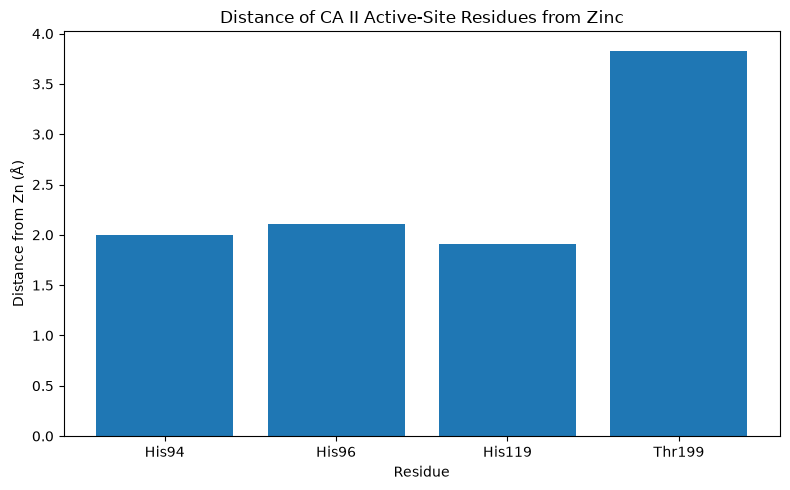

In [62]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

labels = [
    "His94",
    "His96",
    "His119",
    "Thr199"
]

distances = distance_df["Zn_distance_A"]

plt.bar(labels, distances)

plt.xlabel("Residue")
plt.ylabel("Distance from Zn (Å)")
plt.title("Distance of CA II Active-Site Residues from Zinc")

plt.tight_layout()
plt.show()

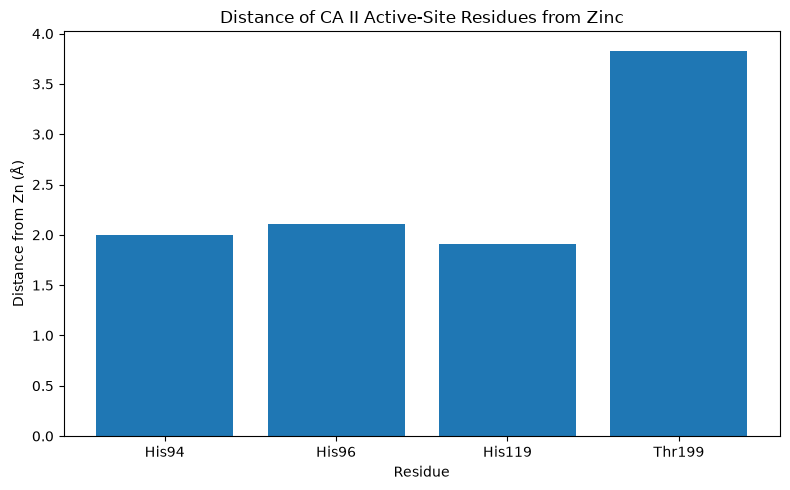

Saved: D:\Drug-Target-Analysis\results\CA2_zinc_residue_distances.png


In [63]:
graph_path = r"D:\Drug-Target-Analysis\results\CA2_zinc_residue_distances.png"

plt.figure(figsize=(8, 5))

plt.bar(labels, distances)

plt.xlabel("Residue")
plt.ylabel("Distance from Zn (Å)")
plt.title("Distance of CA II Active-Site Residues from Zinc")

plt.tight_layout()
plt.savefig(graph_path, dpi=300)
plt.show()

print("Saved:", graph_path)

In [64]:
structural_summary = pd.DataFrame({
    "Parameter": [
        "PDB structure",
        "Protein chain",
        "Resolved residues",
        "Zinc ions",
        "Residues within 4 Å of zinc"
    ],
    "Result": [
        "1CA2",
        "Chain A",
        256,
        1,
        "His94, His96, His119, Thr199"
    ]
})

structural_summary

,Parameter,Result
0,PDB structure,1CA2
1,Protein chain,Chain A
2,Resolved residues,256
3,Zinc ions,1
4,Residues within 4 Å of zinc,"His94, His96, His119, Thr199"


In [65]:
summary_path = r"D:\Drug-Target-Analysis\results\CA2_structural_summary.csv"

structural_summary.to_csv(summary_path, index=False)

print("Saved:", summary_path)

Saved: D:\Drug-Target-Analysis\results\CA2_structural_summary.csv


## Step 12 — Pharmacological Interpretation

Human Carbonic Anhydrase II (CA II) is a zinc-containing enzyme involved in the reversible hydration of carbon dioxide.

The structural analysis identified one zinc ion in the CA II structure. Three histidine residues (His94, His96, and His119) were found very close to the zinc ion, while Thr199 was identified within the 4 Å local environment.

These structural features help define the catalytic region of CA II.

From a pharmaceutical perspective, carbonic anhydrase is an important drug target because modulation of its enzymatic activity can influence physiological processes involving carbon dioxide, bicarbonate, and fluid balance.

In this project, computational structural analysis was used to characterize the protein target before discussing its pharmacological relevance. The analysis demonstrates how sequence information, protein structure, and active-site measurements can be combined with pharmaceutical knowledge.

### B.Pharm Relevance

This project connects pharmaceutical concepts with computational biology through:

1. **Pharmacology:** understanding carbonic anhydrase as an enzyme target.
2. **Biochemistry:** understanding the role of zinc in the catalytic region.
3. **Medicinal chemistry:** relating active-site structure to how molecules can interact with an enzyme target.
4. **Bioinformatics:** analyzing protein sequences and structures computationally.
5. **Drug discovery:** using structural information as an early-stage computational approach for studying potential target–molecule interactions.

Therefore, the project demonstrates how B.Pharm knowledge can be combined with Python, Biopython, structural biology, and computational analysis.